In [1]:
# AUDITORÍA ALGORÍTMICA DE RRHH: PROTOCOLO DE MITIGACIÓN DE SESGOS

# 1. IMPORTACIÓN DE LAS LIBRERÍAS PARA CIENCIA DE DATOS

# Pandas para organizar los datos en tablas
# Numpy para generar los datos y hacer los cálculos
# Matplotlib para crear los gráficos

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Configuración de la visualización de los gráficos
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (10, 5)

In [2]:
# 2. CREACIÓN DEL DATASET SINTÉTICO CON 4 GRUPOS (FASE PRE)

# Para que siempre salgan los mismos números
np.random.seed(42)

# 60 perfiles por cada grupo
n = 60

# Para generar las puntuaciones de cada grupo simulando el sesgo del algoritmo
# Grupo A: Hombres sin laguna -> Puntuaciones altas
# Grupo B: Mujeres con laguna -> Puntuaciones bajas (penalizadas)
# Grupo C: Hombres con laguna -> Puntuaciones altas (no penalizados)
# Grupo D: Mujeres sin laguna -> Puntuaciones altas
puntuacion_A = np.random.normal(83, 6, n)
puntuacion_B = np.random.normal(66, 7, n)
puntuacion_C = np.random.normal(83, 6, n)
puntuacion_D = np.random.normal(80, 6, n)

In [3]:
# 3. ORGANIZACIÓN DE DATOS EN UN DATAFRAME

df = pd.DataFrame({
    'grupo': ['A']*n + ['B']*n + ['C']*n + ['D']*n,
    'sexo': ['Hombres']*n + ['Mujeres']*n + ['Hombres']*n + ['Mujeres']*n,
    'laguna_cuidados': ['No']*n + ['Si']*n + ['Si']*n + ['No']*n,
    'formacion': ['Grado + Máster']*(n*4),
    'experiencia': [8]*(n*4),
    'habilidades': ['Liderazgo, Python, Lean']*(n*4),
    'puntuacion': np.concatenate([puntuacion_A, puntuacion_B, 
                                  puntuacion_C, puntuacion_D]).astype(int)
})

# Para crear la columna "Pasa", 
# 1 si la puntuación sobrepasa 68 puntos
# 0 si no llega
df['pasa'] = (df['puntuacion'] >= 68).astype(int)
df.index = df.index + 1
print("Muestra del dataset")
print(df.head(6))
print(df.tail(6))

import os

carpeta = "resultados"
os.makedirs(carpeta, exist_ok=True)

ruta = os.path.join(carpeta, "dataset_auditoria_rrhh.csv")
df.to_csv(ruta, index=True, encoding="utf-8-sig")
print(f"Dataset guardado correctamente en: {ruta}")

Muestra del dataset
  grupo     sexo laguna_cuidados       formacion  experiencia  \
1     A  Hombres              No  Grado + Máster            8   
2     A  Hombres              No  Grado + Máster            8   
3     A  Hombres              No  Grado + Máster            8   
4     A  Hombres              No  Grado + Máster            8   
5     A  Hombres              No  Grado + Máster            8   
6     A  Hombres              No  Grado + Máster            8   

               habilidades  puntuacion  pasa  
1  Liderazgo, Python, Lean          85     1  
2  Liderazgo, Python, Lean          82     1  
3  Liderazgo, Python, Lean          86     1  
4  Liderazgo, Python, Lean          92     1  
5  Liderazgo, Python, Lean          81     1  
6  Liderazgo, Python, Lean          81     1  
    grupo     sexo laguna_cuidados       formacion  experiencia  \
235     D  Mujeres              No  Grado + Máster            8   
236     D  Mujeres              No  Grado + Máster           

In [4]:
# 4. CÁLCULO DE LAS TASAS DE SELECCIÓN Y LOS RATIOS (FASE PRE)

# La tasa es el porcentaje de cada grupo que pasa
tasa_A = df[df['grupo'] == 'A']['pasa'].mean()
tasa_B = df[df['grupo'] == 'B']['pasa'].mean()
tasa_C = df[df['grupo'] == 'C']['pasa'].mean()
tasa_D = df[df['grupo'] == 'D']['pasa'].mean()

print("Tasas de selección (Fase Pre)")
print(f"Grupo A (Hombres sin laguna): {tasa_A:.1%}")
print(f"Grupo B (Mujeres con laguna): {tasa_B:.1%}")
print(f"Grupo C (Hombres con laguna): {tasa_C:.1%}")
print(f"Grupo D (Mujeres sin laguna): {tasa_D:.1%}")

print("\nRatios de impacto dispar (Fase Pre)")
print(f"A vs B (genero + laguna): {tasa_B/tasa_A:.2f}")
print(f"A vs D (genero puro): {tasa_D/tasa_A:.2f}")
print(f"A vs C (genero en hombres): {tasa_C/tasa_A:.2f}")
print(f"C vs B (laguna hombres vs mujeres): {tasa_B/tasa_C}")

Tasas de selección (Fase Pre)
Grupo A (Hombres sin laguna): 100.0%
Grupo B (Mujeres con laguna): 35.0%
Grupo C (Hombres con laguna): 100.0%
Grupo D (Mujeres sin laguna): 98.3%

Ratios de impacto dispar (Fase Pre)
A vs B (genero + laguna): 0.35
A vs D (genero puro): 0.98
A vs C (genero en hombres): 1.00
C vs B (laguna hombres vs mujeres): 0.35


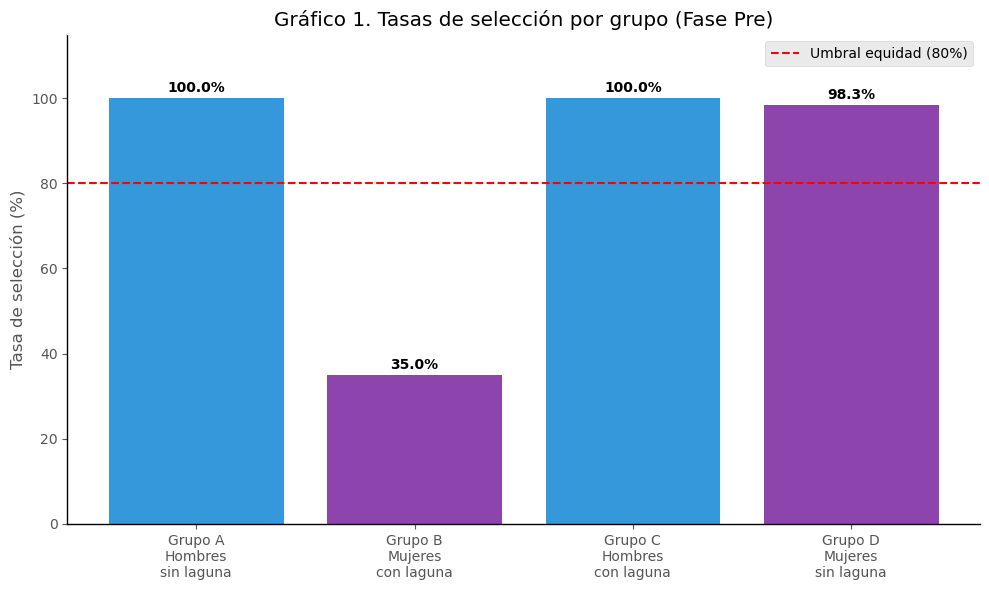

In [5]:
# 5. GRÁFICO DE BARRAS (FASE PRE)

# Para los nombres para cada barra
grupos = ['Grupo A\nHombres\nsin laguna',
          'Grupo B\nMujeres\ncon laguna',
          'Grupo C\nHombres\ncon laguna',
          'Grupo D\nMujeres\nsin laguna']

# Para la altura de las barras (tasas en porcentaje)
tasas = [tasa_A*100, tasa_B*100, tasa_C*100, tasa_D*100]

# Para los colores, azul para hombres, violeta para mujeres
colores = ['#3498db', '#8E44AD', '#3498db', '#8E44AD']

plt.figure(figsize=(10, 6))
plt.gca().set_facecolor('white')
plt.gcf().set_facecolor('white')
barras = plt.bar(grupos, tasas, color=colores)

plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')
plt.gca().spines['bottom'].set_linewidth(1)
plt.gca().spines['left'].set_linewidth(1)

# Para línea roja del umbral del 80%
plt.axhline(y=80, color='red', linestyle='--', label='Umbral equidad (80%)')

# Para poner el porcentaje encima de cada barra
for barra in barras:
    altura = barra.get_height()
    plt.text(barra.get_x() + barra.get_width()/2, altura + 1.5, 
             f'{altura:.1f}%', ha='center', fontweight='bold')

plt.title("Gráfico 1. Tasas de selección por grupo (Fase Pre)")
plt.ylabel("Tasa de selección (%)")
plt.ylim(0, 115)
plt.legend()
plt.tight_layout()
plt.show()

In [6]:
# 6. INFORME AUTOMÁTICO DE CUMPLIMIENTO (FASE PRE)

# Esta función comprueba los ratios y dice si cumple o no la regla del 80%
def revisar_cumplimiento(comparacion, ratio):
    print(f"\nComparacion: {comparacion}")
    print(f"Ratio: {ratio:.2f}")
    if ratio < 0.80:
        print("RESULTADO: SESGO DETECTADO - Incumple regla del 80%")
        print("ACCION: APLICAR PROTOCOLO DE MITIGACION")
    else:
        print("RESULTADO: PROCESO EQUITATIVO - Cumple regla del 80%")

# Para revisar las cuatro comparaciones
revisar_cumplimiento("A vs. B (genero + laguna)",
                      tasa_B/tasa_A)
revisar_cumplimiento("A vs. D (género puro)",
                      tasa_D/tasa_A)
revisar_cumplimiento("A vs. C (laguna en hombres)",
                      tasa_C/tasa_A)
revisar_cumplimiento("C vs. B (laguna hombre vs. mujer)",
                      tasa_B/tasa_C)


Comparacion: A vs. B (genero + laguna)
Ratio: 0.35
RESULTADO: SESGO DETECTADO - Incumple regla del 80%
ACCION: APLICAR PROTOCOLO DE MITIGACION

Comparacion: A vs. D (género puro)
Ratio: 0.98
RESULTADO: PROCESO EQUITATIVO - Cumple regla del 80%

Comparacion: A vs. C (laguna en hombres)
Ratio: 1.00
RESULTADO: PROCESO EQUITATIVO - Cumple regla del 80%

Comparacion: C vs. B (laguna hombre vs. mujer)
Ratio: 0.35
RESULTADO: SESGO DETECTADO - Incumple regla del 80%
ACCION: APLICAR PROTOCOLO DE MITIGACION


In [7]:
# 7. COMPROBACIÓN PERFILES QUE PASAN DE CADA GRUPO

print(df[df['pasa']==1].groupby('grupo').size())

grupo
A    60
B    21
C    60
D    59
dtype: int64


In [8]:
# 7. CREACIÓN DEL DATASET DE LA FASE POST (DESPUÉS DE LA MITIGACIÓN)

# Después de aplicar el protocolo, la laguna ya no penaliza a las mujeres
puntuacion_A_post = puntuacion_A
puntuacion_B_post = np.random.normal(81, 6, n)
puntuacion_C_post = puntuacion_C
puntuacion_D_post = puntuacion_D

df_post = pd.DataFrame({
    'grupo': ['A']*n + ['B']*n + ['C']*n + ['D']*n,
    'puntuacion': np.concatenate([puntuacion_A_post, puntuacion_B_post,
                                  puntuacion_C_post, puntuacion_D_post])
})

df_post['pasa'] = (df_post['puntuacion'] >= 68).astype(int)

# Para calcular las nuevas tasas
tasa_A_post = df_post[df_post['grupo'] == 'A']['pasa'].mean()
tasa_B_post = df_post[df_post['grupo'] == 'B']['pasa'].mean()
tasa_C_post = df_post[df_post['grupo'] == 'C']['pasa'].mean()
tasa_D_post = df_post[df_post['grupo'] == 'D']['pasa'].mean()

ruta_post = os.path.join(carpeta, "dataset_auditoria_rrhh_post.csv")
df_post.to_csv(ruta_post, index=True, encoding="utf-8-sig")
print(f"Dataset post guardado en: {ruta_post}")

Dataset post guardado en: resultados\dataset_auditoria_rrhh_post.csv


In [9]:
# 8. COMPARATIVA DE LAS FASES PRE Y POST

def comparar_pre_post(comparacion, ratio_pre, ratio_post):
    print(f"\n{comparacion}")
    print(f"   Ratio Pre: {ratio_pre:.2f}", 
                "-> Incumple" if ratio_pre < 0.80 else "-> Cumple")
    print(f"   Ratio Post: {ratio_post:.2f}",
                "-> Incumple" if ratio_post < 0.80 else "-> Cumple")

comparar_pre_post("A vs B (gerero + laguna)",
                  tasa_B/tasa_A, tasa_B_post/tasa_A_post)
comparar_pre_post("A vs D (genero puro)",
                  tasa_D/tasa_A, tasa_D_post/tasa_A_post)
comparar_pre_post("A vs C (laguna en hombres)",
                  tasa_C/tasa_A, tasa_C_post/tasa_A_post)
comparar_pre_post("C vs B (laguna hombres vs mujeres)",
                  tasa_B/tasa_C, tasa_B_post/tasa_C_post)


A vs B (gerero + laguna)
   Ratio Pre: 0.35 -> Incumple
   Ratio Post: 0.98 -> Cumple

A vs D (genero puro)
   Ratio Pre: 0.98 -> Cumple
   Ratio Post: 0.98 -> Cumple

A vs C (laguna en hombres)
   Ratio Pre: 1.00 -> Cumple
   Ratio Post: 1.00 -> Cumple

C vs B (laguna hombres vs mujeres)
   Ratio Pre: 0.35 -> Incumple
   Ratio Post: 0.98 -> Cumple


In [10]:
# 9. SISTEMA DE VALIDACIÓN HUMANA (POST - ENTREVISTA)

def validar_candidato (nombre, nota):
    print(f"Candidato/a: {nombre}")
    print(f"Puntuación entrevista: {nota}/5")

    # Si la nota es baja, el sistema debe avisar de un posible sesgo
    if nota < 3.5:
        print("RESULTADO: Revisión necesaria")
        print("AVISO: Comprobar si hay sesgo por cuidados.")
    else:
        print("RESULTADO: Candidato/a Apto/a")

    print() # Línea en blanco para separar los perfiles

# Ejemplo de uso, solo hay que introducir el nombre + id y la nota
validar_candidato("Maria (ID:043)", 4.5)

validar_candidato("Ana (ID:067)", 3.0)

Candidato/a: Maria (ID:043)
Puntuación entrevista: 4.5/5
RESULTADO: Candidato/a Apto/a

Candidato/a: Ana (ID:067)
Puntuación entrevista: 3.0/5
RESULTADO: Revisión necesaria
AVISO: Comprobar si hay sesgo por cuidados.



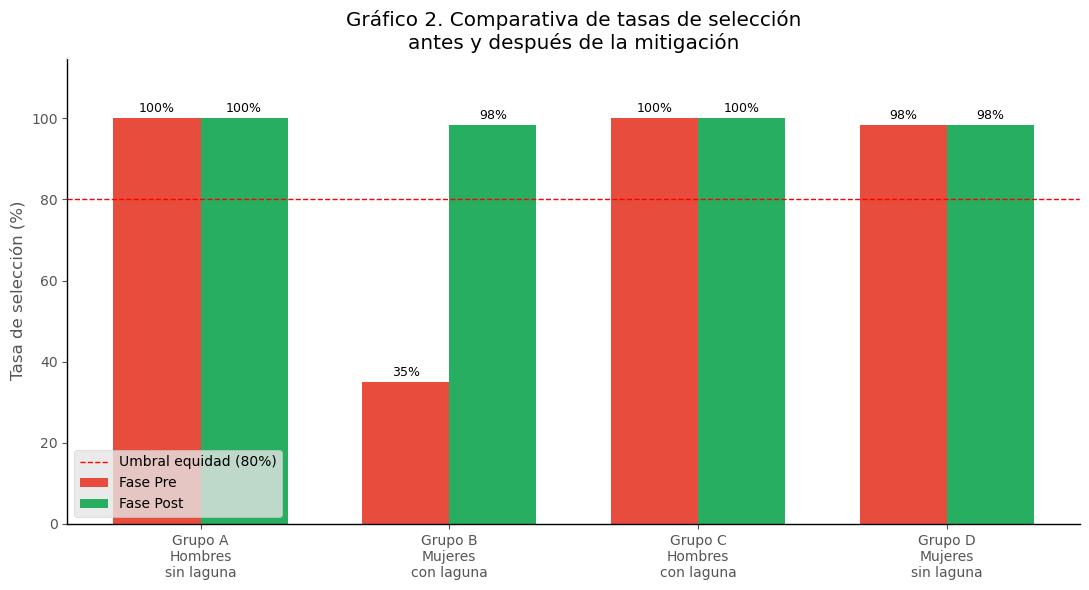

In [11]:
# 10. GRÁFICO COMPARATIVO PRE VS POST

grupos = ['Grupo A\nHombres\nsin laguna',
          'Grupo B\nMujeres\ncon laguna',
          'Grupo C\nHombres\ncon laguna',
          'Grupo D\nMujeres\nsin laguna']

# Para las tasas de cada fase en porcentajes
tasas_pre = [tasa_A*100, tasa_B*100, tasa_C*100, 
             tasa_D*100]
tasas_post = [tasa_A_post*100, tasa_B_post*100, 
              tasa_C_post*100, tasa_D_post*100]

# Para la posición de las barras en el eje X
x = np.arange(len(grupos))
ancho = 0.35

plt.figure(figsize=(11, 6))
plt.gca().set_facecolor('white')
plt.gcf().set_facecolor('white')

# Para dibujar las dos series de barras (pre y post)
barras_pre = plt.bar(x - ancho/2, tasas_pre, ancho,
                     label='Fase Pre', color='#E74C3C')
barras_post = plt.bar(x + ancho/2, tasas_post, ancho,
                      label='Fase Post', color='#27AE60')

# Para la línea roja del umbrasl de 80%
plt.axhline(y=80, color='red', linestyle="--", linewidth=1,
            label='Umbral equidad (80%)')

# Para el porcentaje encima de cada barra
for barra in barras_pre:
    altura = barra.get_height()
    plt.text(barra.get_x() + barra.get_width()/2, altura + 1.5,
             f'{altura:.0f}%', ha='center', fontsize=9)

for barra in barras_post:
    altura = barra.get_height()
    plt.text(barra.get_x() + barra.get_width()/2, altura + 1.5,
             f'{altura:.0f}%', ha='center', fontsize=9)

# Para las líneas de los ejes
plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')

plt.title('Gráfico 2. Comparativa de tasas de selección\nantes y después de la mitigación')
plt.ylabel('Tasa de selección (%)')
plt.xticks(x, grupos)
plt.ylim(0, 115)
plt.legend()
plt.tight_layout()
plt.show()
    